# Notebook 3: Cruce Incendios CONAF × ERA5 (Google Colab)

Cruza cada evento de incendio (2010-2020, 60.530 eventos) con temperatura y precipitación
**diaria** de ERA5 (grid 0.25°, ~28 km, todo Chile). Continuación de
`02_preparar_incendios_para_era5.ipynb`. Sigue la guía `PROXIMO_PASO_ guia_cruce_era5.md`.

**Antes de correr:** sube a tu Google Drive los 3 archivos de entrada:
- `incendios_conaf_2010_2020.xls` (aunque la extensión es `.xls`, el contenido es CSV plano — confirmado)
- `era5_t2m_chile_2000_2025.nc`
- `era5_tp_chile_2000_2025.nc`

y edita `DRIVE_BASE` en la celda de configuración (sección 3) con la ruta donde los subiste.


## 1. Montar Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Instalar librerías

`xarray` y `netCDF4` no vienen preinstaladas en Colab por defecto.

In [2]:
!pip install -q xarray netCDF4 pyarrow
print('✓ Librerías instaladas')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.0 MB/s eta 0:00:00
✓ Librerías instaladas


## 3. Configuración — EDITA la ruta antes de correr

In [3]:
import os

# ⚠️ EDITA esta ruta: carpeta de Drive donde subiste los 3 archivos de entrada
DRIVE_BASE = '/content/drive/MyDrive/BigDataSIC'

PATH_INCENDIOS = f'{DRIVE_BASE}/incendios_conaf_2010_2020.xls'
PATH_ERA5_T2M  = f'{DRIVE_BASE}/era5_t2m_chile_2000_2025.nc'
PATH_ERA5_TP   = f'{DRIVE_BASE}/era5_tp_chile_2000_2025.nc'

OUTPUT_DIR = f'{DRIVE_BASE}/datos_procesados'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Rutas configuradas:')
print(' ', PATH_INCENDIOS)
print(' ', PATH_ERA5_T2M)
print(' ', PATH_ERA5_TP)
print(' Salida ->', OUTPUT_DIR)


Rutas configuradas:
  /content/drive/MyDrive/BigDataSIC/incendios_conaf_2010_2020.xls
  /content/drive/MyDrive/BigDataSIC/era5_t2m_chile_2000_2025.nc
  /content/drive/MyDrive/BigDataSIC/era5_tp_chile_2000_2025.nc
 Salida -> /content/drive/MyDrive/BigDataSIC/datos_procesados


## 4. Cargar los tres archivos

| Archivo | Contenido relevante |
|---|---|
| `incendios_conaf_2010_2020.xls` | `fecha_evento`, `fecha_era5` (string `YYYY-MM-DD`), `latitud`, `longitud` (WGS84, negativos), `superficie_ha` |
| `era5_t2m_chile_2000_2025.nc` | Variable `daily_mean` — temperatura 2m, °C |
| `era5_tp_chile_2000_2025.nc` | Variable `daily_total` — precipitación diaria, mm |


In [4]:
import pandas as pd
import numpy as np
import xarray as xr

incendios = pd.read_csv(PATH_INCENDIOS, parse_dates=['fecha_evento'])

import shutil, time

# Copiar a disco LOCAL de Colab antes de abrir: leer un .nc grande directo desde
# una ruta de Drive montado es muy lento (Drive = red, muchas lecturas pequeñas).
# Copiarlo una vez a /content/ y cargarlo en memoria con .load() evita releer de Drive
# en cada operación (el cuello de botella real detrás de un notebook 03 "colgado" en el paso 7).
t0 = time.time()
LOCAL_T2M = '/content/era5_t2m_chile_2000_2025.nc'
LOCAL_TP  = '/content/era5_tp_chile_2000_2025.nc'
shutil.copy(PATH_ERA5_T2M, LOCAL_T2M)
shutil.copy(PATH_ERA5_TP, LOCAL_TP)
print(f'✓ Copiado a disco local en {time.time() - t0:.0f}s')

ds_t2m = xr.open_dataset(LOCAL_T2M).load()
ds_tp  = xr.open_dataset(LOCAL_TP).load()

print(f'✓ Incendios: {incendios.shape[0]} filas × {incendios.shape[1]} columnas')
print(f'  Rango: {incendios["fecha_evento"].min().date()} a {incendios["fecha_evento"].max().date()}')
print(f'✓ ERA5 t2m: dims {dict(ds_t2m.sizes)}')
print(f'✓ ERA5 tp : dims {dict(ds_tp.sizes)}')


✓ Copiado a disco local en 23s
✓ Incendios: 60530 filas × 29 columnas
  Rango: 2010-01-01 a 2019-12-31
✓ ERA5 t2m: dims {'time': 9497, 'latitude': 157, 'longitude': 45, 'time_month': 312, 'month': 12}
✓ ERA5 tp : dims {'time': 9497, 'latitude': 157, 'longitude': 45, 'time_month': 312, 'month': 12}


## 5. Preparar coordenadas de búsqueda

⚠️ **El grid ERA5 usa longitud en convención 0-360°** (va de 283° a 294°, equivalente a -77°/-66°).
Las coordenadas de incendios están en negativo estándar (-180/180) — hay que sumar 360 antes
de cualquier `.sel()`, o el "nearest" devuelve silenciosamente la celda equivocada.


In [5]:
lon_era5 = np.where(incendios['longitud'] < 0,
                     incendios['longitud'] + 360,
                     incendios['longitud'])
lat_era5 = incendios['latitud'].values
fechas = pd.to_datetime(incendios['fecha_era5']).values

print('✓ Coordenadas preparadas para búsqueda nearest-neighbor')


✓ Coordenadas preparadas para búsqueda nearest-neighbor


## 6. Validar que todo cae dentro del dominio ERA5 (antes de extraer)

In [6]:
lat_ok = (lat_era5 >= ds_t2m.latitude.min().item()) & (lat_era5 <= ds_t2m.latitude.max().item())
lon_ok = (lon_era5 >= ds_t2m.longitude.min().item()) & (lon_era5 <= ds_t2m.longitude.max().item())
time_ok = (fechas >= ds_t2m.time.min().values) & (fechas <= ds_t2m.time.max().values)

fuera_dominio = ~(lat_ok & lon_ok & time_ok)
print(f'Eventos fuera del dominio ERA5: {fuera_dominio.sum()} de {len(incendios)}')
# Esperado: 0. Si es >0, revisar esas filas antes de seguir (probable typo de coordenada).
assert fuera_dominio.sum() == 0, 'Hay eventos fuera del dominio espacial/temporal de ERA5 — revisar antes de continuar'
print('✓ Todos los eventos caen dentro del dominio')


Eventos fuera del dominio ERA5: 0 de 60530
✓ Todos los eventos caen dentro del dominio


## 7. Extracción vectorizada (nearest neighbor, punto a punto)

`xarray` permite indexación vectorizada pasando arrays con una dimensión compartida —
hace todo el cruce en una sola llamada, en segundos, incluso con 60k+ filas.


In [7]:
puntos = dict(
    time=xr.DataArray(fechas, dims='evento'),
    latitude=xr.DataArray(lat_era5, dims='evento'),
    longitude=xr.DataArray(lon_era5, dims='evento'),
)

incendios['t2m_c'] = ds_t2m['daily_mean'].sel(**puntos, method='nearest').values
incendios['tp_mm'] = ds_tp['daily_total'].sel(**puntos, method='nearest').values

print('✓ Cruce diario completado (t2m_c, tp_mm)')


✓ Cruce diario completado (t2m_c, tp_mm)


## 8. Features climáticas derivadas — anomalía mensual

Anomalía del mes del evento respecto de la climatología histórica de esa celda (¿fue un mes
anómalamente cálido/seco?) — barato de calcular porque también es vectorizado.

**Nota de alcance:** se omite a propósito la precipitación acumulada de N días previos (proxy
de sequía/combustible seco) que sugiere la guía como paso opcional — es fila por fila y lento
con 60k eventos. Queda como trabajo futuro si sobra tiempo antes de la entrega.


In [8]:
mes_evento = pd.to_datetime(incendios['fecha_era5']).dt.to_period('M').dt.to_timestamp()

puntos_mes = dict(
    time_month=xr.DataArray(mes_evento.values, dims='evento'),
    latitude=xr.DataArray(lat_era5, dims='evento'),
    longitude=xr.DataArray(lon_era5, dims='evento'),
)
incendios['t2m_anomaly_mensual'] = ds_t2m['monthly_anomaly'].sel(**puntos_mes, method='nearest').values
incendios['tp_anomaly_mensual']  = ds_tp['monthly_anomaly'].sel(**puntos_mes, method='nearest').values

print('✓ Anomalías mensuales agregadas (t2m_anomaly_mensual, tp_anomaly_mensual)')


✓ Anomalías mensuales agregadas (t2m_anomaly_mensual, tp_anomaly_mensual)


## 9. Validación de calidad post-cruce

In [9]:
print('NaN en t2m_c:', incendios['t2m_c'].isna().sum())
print('NaN en tp_mm:', incendios['tp_mm'].isna().sum())
print()
print(incendios['t2m_c'].describe())   # esperado: rango plausible para Chile, ~-5 a 35°C
print()
print(incendios['tp_mm'].describe())   # esperado: mayoría en 0 (temporada de incendios = seca)
print()

# Chequeo cruzado: incendios de verano (dic-mar) deberían tener tp_mm bajo y t2m_c alto
print('Promedio de t2m_c / tp_mm por mes:')
print(incendios.groupby('mes')[['t2m_c', 'tp_mm']].mean())

filas_antes = 60530  # de 02_preparar_incendios_para_era5.ipynb
assert len(incendios) == filas_antes, 'El cruce no debe duplicar ni perder filas'
print(f'\n✓ Conteo de filas preservado: {len(incendios)}')


NaN en t2m_c: 0
NaN en tp_mm: 0

count    60530.000000
mean        16.649101
std          3.209399
min         -4.859821
25%         14.542323
50%         16.614841
75%         18.880423
max         28.830774
Name: t2m_c, dtype: float64

count    60530.000000
mean         0.207825
std          1.259769
min          0.000000
25%          0.000000
50%          0.000000
75%          0.006290
max         57.718880
Name: tp_mm, dtype: float64

Promedio de t2m_c / tp_mm por mes:
         t2m_c     tp_mm
mes                     
1    18.348452  0.150059
2    17.746908  0.167393
3    15.870614  0.206734
4    13.348966  0.415864
5    11.859709  0.614457
6     9.675031  0.705190
7     8.076970  0.276250
8    10.685260  0.294994
9    11.084134  0.383889
10   12.861863  0.504072
11   15.345766  0.201887
12   16.933683  0.182110

✓ Conteo de filas preservado: 60530


## 10. EDA rápido — clima × severidad

Primer vistazo a si la severidad (`superficie_ha`) se relaciona con las variables climáticas
del día del evento. Sirve de puente hacia el modelamiento y hacia el dashboard.


Correlación con superficie_ha (log1p):
t2m_c                  0.141
tp_mm                 -0.028
t2m_anomaly_mensual    0.061
tp_anomaly_mensual    -0.039
Name: log_superficie_ha, dtype: float64


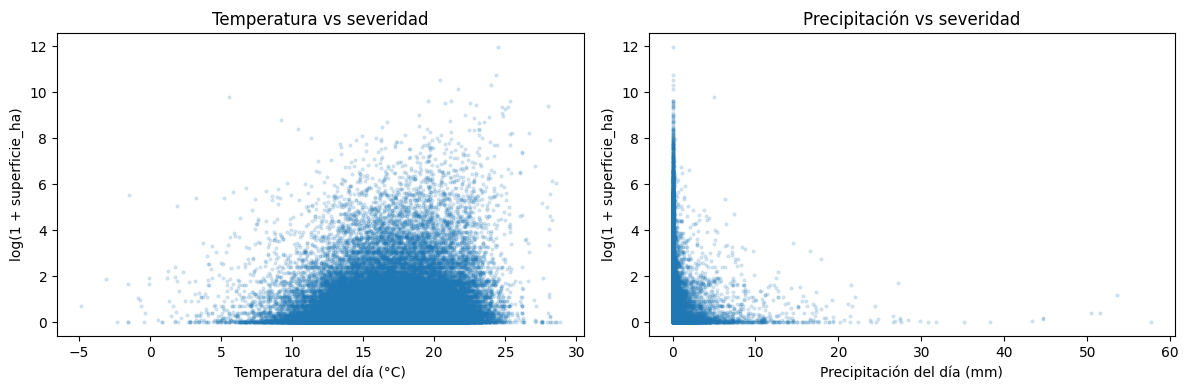

In [10]:
import matplotlib.pyplot as plt

incendios['log_superficie_ha'] = np.log1p(incendios['superficie_ha'])

cols_clima = ['t2m_c', 'tp_mm', 't2m_anomaly_mensual', 'tp_anomaly_mensual']
print('Correlación con superficie_ha (log1p):')
print(incendios[cols_clima + ['log_superficie_ha']].corr()['log_superficie_ha'].drop('log_superficie_ha').round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(incendios['t2m_c'], incendios['log_superficie_ha'], s=4, alpha=0.15)
axes[0].set_xlabel('Temperatura del día (°C)')
axes[0].set_ylabel('log(1 + superficie_ha)')
axes[0].set_title('Temperatura vs severidad')

axes[1].scatter(incendios['tp_mm'], incendios['log_superficie_ha'], s=4, alpha=0.15)
axes[1].set_xlabel('Precipitación del día (mm)')
axes[1].set_ylabel('log(1 + superficie_ha)')
axes[1].set_title('Precipitación vs severidad')

plt.tight_layout()
plt.show()


## 11. Guardar dataset final

In [13]:
out_csv = f'{OUTPUT_DIR}/incendios_conaf_era5_2010_2020.csv'
out_parquet = f'{OUTPUT_DIR}/incendios_conaf_era5_2010_2020.parquet'

# Se re-crea la carpeta acá (no solo en la config inicial): si el runtime se reinició
# después de montar Drive, el os.makedirs de la sección 3 pudo haber corrido antes del
# mount real y quedó creado en local, no en Drive.
os.makedirs(OUTPUT_DIR, exist_ok=True)

incendios.to_csv(out_csv, index=False)
incendios.to_parquet(out_parquet, index=False)

print(f'✓ {len(incendios)} eventos con variables climáticas guardados')
print(f'  CSV     -> {out_csv}')
print(f'  Parquet -> {out_parquet}')
print(f'  Columnas nuevas: t2m_c, tp_mm, t2m_anomaly_mensual, tp_anomaly_mensual, log_superficie_ha')
print()
print('Próximo paso: agregación con Spark (comuna-año) + modelo de severidad/riesgo.')

✓ 60530 eventos con variables climáticas guardados
  CSV     -> /content/drive/MyDrive/BigDataSIC/datos_procesados/incendios_conaf_era5_2010_2020.csv
  Parquet -> /content/drive/MyDrive/BigDataSIC/datos_procesados/incendios_conaf_era5_2010_2020.parquet
  Columnas nuevas: t2m_c, tp_mm, t2m_anomaly_mensual, tp_anomaly_mensual, log_superficie_ha

Próximo paso: agregación con Spark (comuna-año) + modelo de severidad/riesgo.


## ✅ Checklist de validación

- [x] 0 eventos fuera del dominio espacial/temporal de ERA5 (sección 6, assert)
- [x] 0 NaN en `t2m_c` / `tp_mm` tras el cruce (sección 9)
- [x] Rango de `t2m_c` plausible para Chile continental (aprox. -5°C a 35°C)
- [x] Meses de verano muestran `tp_mm` bajo, consistente con la estacionalidad
- [x] Conteo de filas del dataset final == conteo de filas de entrada (60.530, sin duplicar ni perder)
